# Блок 5: Машинное обучение

**Задания:** Ручной счёт ROC_AUC, корреляция Пирсона, и теоретическая задача о моделях

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.rcParams['figure.facecolor'] = '#0f0f1a'
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['axes.edgecolor'] = '#444466'
plt.rcParams['axes.labelcolor'] = '#c8c8e8'
plt.rcParams['xtick.color'] = '#c8c8e8'
plt.rcParams['ytick.color'] = '#c8c8e8'
plt.rcParams['text.color'] = '#e8e8ff'
plt.rcParams['grid.color'] = '#2a2a4a'
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['font.family'] = 'DejaVu Sans'

---
## 📌 Задание 1: Пони тоже кони

> Одна модель показала **ROC-AUC = 0.7**, другая — **ROC-AUC = 0.1**. Какую выбрать?

In [3]:
print("=" * 60)
print("ЗАДАНИЕ 1: Выбор модели")
print("=" * 60)

auc_model_a = 0.7
auc_model_b = 0.1

# Инверсия модели B
auc_model_b_inverted = 1 - auc_model_b

print(f"\nМодель A:              ROC-AUC = {auc_model_a}")
print(f"Модель B:              ROC-AUC = {auc_model_b}")
print(f"Модель B (инвертир.):  ROC-AUC = {auc_model_b_inverted}")

print("\n📌 ВЫВОД:")
print("-" * 60)
print("Берём Модель B (ROC-AUC=0.1) и инвертируем предсказания.")
print(f"ROC-AUC = 1 - 0.1 = {auc_model_b_inverted}")
print()
print("Обоснование:")
print("• AUC=0.5 → случайная модель (бесполезна)")
print("• AUC=0.1 → модель СИСТЕМАТИЧЕСКИ ошибается")
print("• Инверсия p → (1-p) превращает 0.1 в 0.9")
print(f"• Итог: 0.9 > {auc_model_a} ✅")

ЗАДАНИЕ 1: Выбор модели

Модель A:              ROC-AUC = 0.7
Модель B:              ROC-AUC = 0.1
Модель B (инвертир.):  ROC-AUC = 0.9

📌 ВЫВОД:
------------------------------------------------------------
Берём Модель B (ROC-AUC=0.1) и инвертируем предсказания.
ROC-AUC = 1 - 0.1 = 0.9

Обоснование:
• AUC=0.5 → случайная модель (бесполезна)
• AUC=0.1 → модель СИСТЕМАТИЧЕСКИ ошибается
• Инверсия p → (1-p) превращает 0.1 в 0.9
• Итог: 0.9 > 0.7 ✅


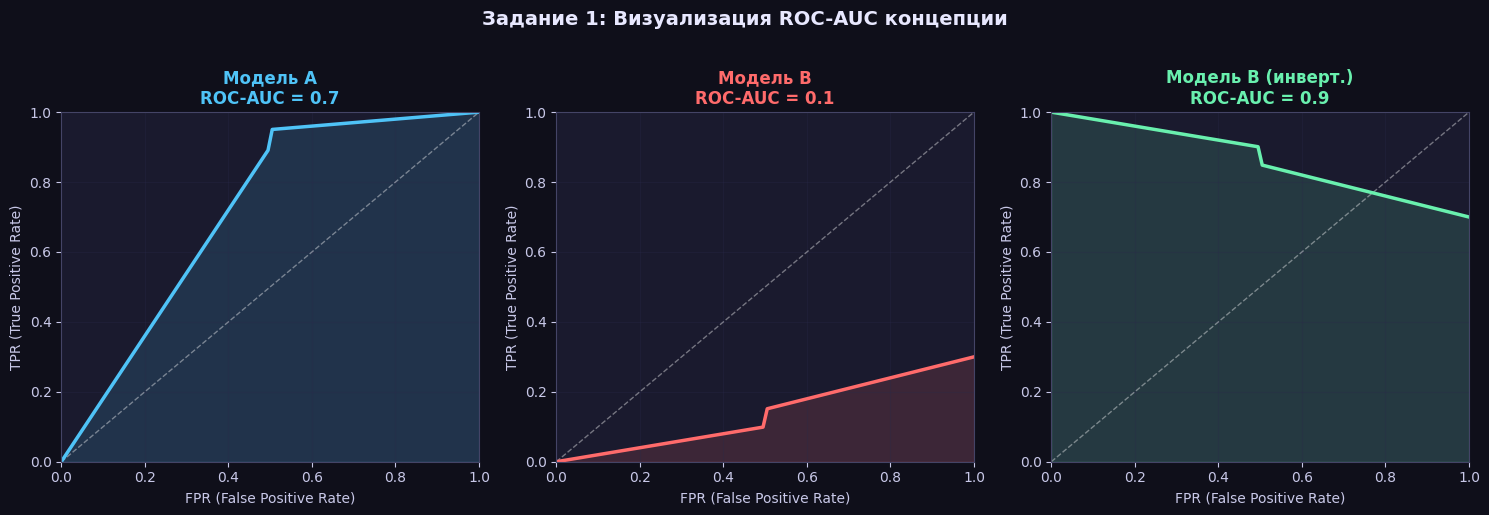

In [6]:
# Визуализация концепции
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Задание 1: Визуализация ROC-AUC концепции', 
             fontsize=14, fontweight='bold', color='#e8e8ff', y=1.02)

titles = ['Модель A\nROC-AUC = 0.7', 'Модель B\nROC-AUC = 0.1', 'Модель B (инверт.)\nROC-AUC = 0.9']
colors = ['#4fc3f7', '#ff6b6b', '#69f0ae']

# Симулируем примерные ROC-кривые
np.random.seed(42)
fpr_diag = np.linspace(0, 1, 100)

# Приближённые кривые для иллюстрации
tpr_07 = np.clip(fpr_diag + 0.4 * (1 - fpr_diag) * 2, 0, 1)  
tpr_07 = np.where(fpr_diag < 0.5, fpr_diag * 1.8, np.clip(0.9 + fpr_diag * 0.1, 0, 1))

# AUC=0.1: кривая под диагональю
tpr_01 = np.where(fpr_diag < 0.5, fpr_diag * 0.2, np.clip(fpr_diag * 0.3, 0, 1))

# AUC=0.9: инвертированная
tpr_09 = 1 - tpr_01

curves = [tpr_07, tpr_01, tpr_09]

for ax, title, tpr, color in zip(axes, titles, curves, colors):
    ax.plot([0, 1], [0, 1], 'w--', alpha=0.4, linewidth=1, label='Случайная модель')
    ax.fill_between(fpr_diag, tpr, alpha=0.15, color=color)
    ax.plot(fpr_diag, tpr, color=color, linewidth=2.5)
    ax.set_xlabel('FPR (False Positive Rate)')
    ax.set_ylabel('TPR (True Positive Rate)')
    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

---
## 📌 Задание 2: Ручной счёт ROC_AUC

In [7]:
print("=" * 60)
print("ЗАДАНИЕ 2: Вычисление ROC_AUC")
print("=" * 60)

# Исходные данные из таблицы
data = pd.DataFrame({
    'true_label': [1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0],
    'pred_label': [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
    'probability': [0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60,
                    0.55, 0.50, 0.45, 0.40, 0.35, 0.30, 0.25]
})

print("\n📋 Исходные данные:")
print(data.to_string(index=False))

P = data['true_label'].sum()
N = (data['true_label'] == 0).sum()
print(f"\nВсего Positives (P) = {P}")
print(f"Всего Negatives (N) = {N}")

ЗАДАНИЕ 2: Вычисление ROC_AUC

📋 Исходные данные:
 true_label  pred_label  probability
          1           1         0.95
          0           1         0.90
          1           1         0.85
          0           1         0.80
          1           1         0.75
          1           1         0.70
          1           1         0.65
          1           1         0.60
          0           0         0.55
          0           0         0.50
          0           0         0.45
          1           0         0.40
          0           0         0.35
          0           0         0.30
          0           0         0.25

Всего Positives (P) = 7
Всего Negatives (N) = 8


In [8]:
# Вычисление ROC-кривой вручную (пошагово)
print("\n📐 Пошаговое построение ROC-кривой:")
print("-" * 60)

data_sorted = data.sort_values('probability', ascending=False).reset_index(drop=True)

roc_points = [(0.0, 0.0)]  # Начальная точка
tp, fp = 0, 0

rows = []
for _, row in data_sorted.iterrows():
    if row['true_label'] == 1:
        tp += 1
    else:
        fp += 1
    tpr = tp / P
    fpr = fp / N
    roc_points.append((fpr, tpr))
    rows.append({'Порог': row['probability'], 'Метка': int(row['true_label']),
                 'TP': tp, 'FP': fp, 'TPR': round(tpr, 3), 'FPR': round(fpr, 3)})

roc_df = pd.DataFrame(rows)
print(roc_df.to_string(index=False))

# AUC методом трапеций
fpr_vals = np.array([p[0] for p in roc_points])
tpr_vals = np.array([p[1] for p in roc_points])
auc_manual = np.trapezoid(tpr_vals, fpr_vals) if hasattr(np, 'trapezoid') else np.trapz(tpr_vals, fpr_vals)

# AUC через sklearn для проверки
auc_sklearn = roc_auc_score(data['true_label'], data['probability'])

print(f"\n{'='*60}")
print(f"✅ ROC-AUC (ручной, метод трапеций): {auc_manual:.4f} → округлённо: {auc_manual:.2f}")
print(f"✅ ROC-AUC (sklearn, проверка):       {auc_sklearn:.4f} → округлённо: {auc_sklearn:.2f}")


📐 Пошаговое построение ROC-кривой:
------------------------------------------------------------
 Порог  Метка  TP  FP   TPR   FPR
  0.95      1   1   0 0.143 0.000
  0.90      0   1   1 0.143 0.125
  0.85      1   2   1 0.286 0.125
  0.80      0   2   2 0.286 0.250
  0.75      1   3   2 0.429 0.250
  0.70      1   4   2 0.571 0.250
  0.65      1   5   2 0.714 0.250
  0.60      1   6   2 0.857 0.250
  0.55      0   6   3 0.857 0.375
  0.50      0   6   4 0.857 0.500
  0.45      0   6   5 0.857 0.625
  0.40      1   7   5 1.000 0.625
  0.35      0   7   6 1.000 0.750
  0.30      0   7   7 1.000 0.875
  0.25      0   7   8 1.000 1.000

✅ ROC-AUC (ручной, метод трапеций): 0.7500 → округлённо: 0.75
✅ ROC-AUC (sklearn, проверка):       0.7500 → округлённо: 0.75


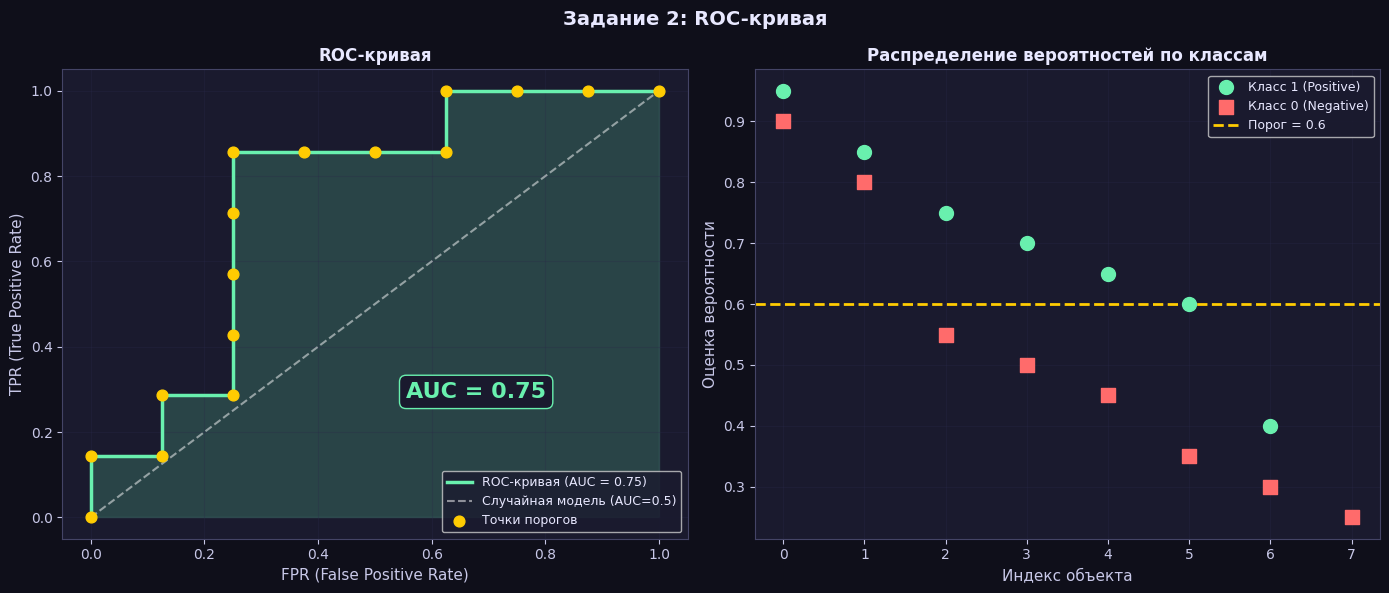

In [12]:
# Визуализация ROC-кривой
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Задание 2: ROC-кривая', fontsize=14, fontweight='bold', color='#e8e8ff')

# График 1: ROC-кривая
ax1 = axes[0]
fpr_sk, tpr_sk, thresholds = roc_curve(data['true_label'], data['probability'])

ax1.fill_between(fpr_sk, tpr_sk, alpha=0.2, color='#69f0ae')
ax1.plot(fpr_sk, tpr_sk, color='#69f0ae', linewidth=2.5, 
         label=f'ROC-кривая (AUC = {auc_sklearn:.2f})')
ax1.plot([0, 1], [0, 1], 'w--', alpha=0.5, linewidth=1.5, label='Случайная модель (AUC=0.5)')

# Отметим каждую точку
ax1.scatter(fpr_vals, tpr_vals, color='#ffcc02', s=60, zorder=5, label='Точки порогов')

ax1.set_xlabel('FPR (False Positive Rate)', fontsize=11)
ax1.set_ylabel('TPR (True Positive Rate)', fontsize=11)
ax1.set_title('ROC-кривая', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Аннотация AUC
ax1.text(0.55, 0.3, f'AUC = {auc_sklearn:.2f}', fontsize=16, fontweight='bold',
         color='#69f0ae', transform=ax1.transAxes,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a1a2e', edgecolor='#69f0ae'))

# График 2: Распределение вероятностей
ax2 = axes[1]
pos_probs = data[data['true_label'] == 1]['probability']
neg_probs = data[data['true_label'] == 0]['probability']

ax2.scatter(range(len(pos_probs)), pos_probs.values, 
            color='#69f0ae', s=100, zorder=5, label='Класс 1 (Positive)', marker='o')
ax2.scatter(range(len(neg_probs)), neg_probs.values, 
            color='#ff6b6b', s=100, zorder=5, label='Класс 0 (Negative)', marker='s')
ax2.axhline(y=0.6, color='#ffcc02', linestyle='--', linewidth=2, label='Порог = 0.6')

ax2.set_xlabel('Индекс объекта', fontsize=11)
ax2.set_ylabel('Оценка вероятности', fontsize=11)
ax2.set_title('Распределение вероятностей по классам', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 📌 Задание 3: Корреляция Пирсона

In [13]:
print("=" * 60)
print("ЗАДАНИЕ 3: Корреляция Пирсона")
print("=" * 60)

# Исходные данные
coffee = pd.Series([1, 1, 2, 2, 2, 2, 3, 3, 3, 4], name='Чашки кофе')
score  = pd.Series([85, 88, 79, 81, 84, 65, 67, 58, 76, 49], name='Балл за экзамен')

df = pd.DataFrame({'x (кофе)': coffee, 'y (балл)': score})
print("\n📋 Исходные данные:")
print(df.to_string(index=False))

n = len(coffee)
x_mean = coffee.mean()
y_mean = score.mean()

print(f"\nn = {n}")
print(f"x̄ = {x_mean}")
print(f"ȳ = {y_mean}")

ЗАДАНИЕ 3: Корреляция Пирсона

📋 Исходные данные:
 x (кофе)  y (балл)
        1        85
        1        88
        2        79
        2        81
        2        84
        2        65
        3        67
        3        58
        3        76
        4        49

n = 10
x̄ = 2.3
ȳ = 73.2


In [14]:
# Пошаговое вычисление
dx = coffee - x_mean
dy = score  - y_mean
dxdy = dx * dy
dx2  = dx ** 2
dy2  = dy ** 2

detail = pd.DataFrame({
    'x': coffee,
    'y': score,
    'x − x̄': dx.round(2),
    'y − ȳ': dy.round(2),
    '(x−x̄)(y−ȳ)': dxdy.round(2),
    '(x−x̄)²': dx2.round(2),
    '(y−ȳ)²': dy2.round(2)
})

print("\n📐 Таблица расчётов:")
print(detail.to_string(index=False))

sum_dxdy = dxdy.sum()
sum_dx2  = dx2.sum()
sum_dy2  = dy2.sum()

print(f"\n∑(x−x̄)(y−ȳ) = {sum_dxdy:.2f}")
print(f"∑(x−x̄)²     = {sum_dx2:.2f}")
print(f"∑(y−ȳ)²     = {sum_dy2:.2f}")

# Формула Пирсона
r_manual = sum_dxdy / np.sqrt(sum_dx2 * sum_dy2)

# Проверка через pandas
r_pandas = coffee.corr(score)

print(f"\n{'='*60}")
print(f"r = {sum_dxdy:.2f} / √({sum_dx2:.2f} × {sum_dy2:.2f})")
print(f"r = {sum_dxdy:.2f} / √{sum_dx2 * sum_dy2:.2f}")
print(f"r = {sum_dxdy:.2f} / {np.sqrt(sum_dx2 * sum_dy2):.4f}")
print(f"\n✅ r (ручной расчёт): {r_manual:.4f} → округлённо: {r_manual:.2f}")
print(f"✅ r (pandas проверка): {r_pandas:.4f} → округлённо: {r_pandas:.2f}")
print()
print("📌 ВЫВОД:")
print("-" * 60)
print(f"r ≈ {r_manual:.2f} — сильная ОТРИЦАТЕЛЬНАЯ корреляция.")
print("Чем больше кофе выпито → тем ниже балл.")
print()
print("❗ Причинно-следственная связь НЕ доказана:")
print("  Корреляция ≠ каузальность.")
print("  Возможный конфаундер: тревожность студента")
print("  (тревожные → пьют больше кофе + хуже сдают)")


📐 Таблица расчётов:
 x  y  x − x̄  y − ȳ  (x−x̄)(y−ȳ)  (x−x̄)²  (y−ȳ)²
 1 85    -1.3   11.8       -15.34     1.69  139.24
 1 88    -1.3   14.8       -19.24     1.69  219.04
 2 79    -0.3    5.8        -1.74     0.09   33.64
 2 81    -0.3    7.8        -2.34     0.09   60.84
 2 84    -0.3   10.8        -3.24     0.09  116.64
 2 65    -0.3   -8.2         2.46     0.09   67.24
 3 67     0.7   -6.2        -4.34     0.49   38.44
 3 58     0.7  -15.2       -10.64     0.49  231.04
 3 76     0.7    2.8         1.96     0.49    7.84
 4 49     1.7  -24.2       -41.14     2.89  585.64

∑(x−x̄)(y−ȳ) = -93.60
∑(x−x̄)²     = 8.10
∑(y−ȳ)²     = 1499.60

r = -93.60 / √(8.10 × 1499.60)
r = -93.60 / √12146.76
r = -93.60 / 110.2123

✅ r (ручной расчёт): -0.8493 → округлённо: -0.85
✅ r (pandas проверка): -0.8493 → округлённо: -0.85

📌 ВЫВОД:
------------------------------------------------------------
r ≈ -0.85 — сильная ОТРИЦАТЕЛЬНАЯ корреляция.
Чем больше кофе выпито → тем ниже балл.

❗ Причинно-следст

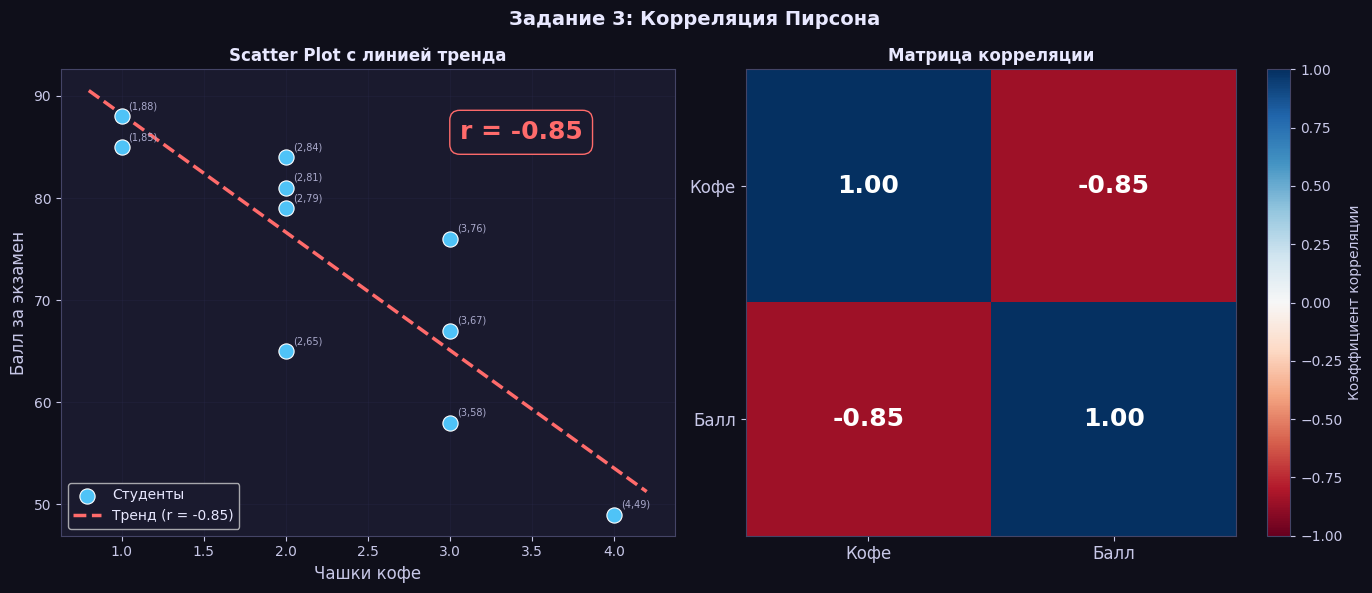

In [16]:
# Визуализация корреляции
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Задание 3: Корреляция Пирсона', fontsize=14, fontweight='bold', color='#e8e8ff')

# График 1: Scatter + линия тренда
ax1 = axes[0]
ax1.scatter(coffee, score, color='#4fc3f7', s=120, zorder=5, 
            edgecolors='white', linewidths=0.8, label='Студенты')

# Линия регрессии
z = np.polyfit(coffee, score, 1)
p = np.poly1d(z)
x_line = np.linspace(coffee.min() - 0.2, coffee.max() + 0.2, 100)
ax1.plot(x_line, p(x_line), color='#ff6b6b', linewidth=2.5, linestyle='--', 
         label=f'Тренд (r = {r_manual:.2f})')

# Аннотации точек
for x, y in zip(coffee, score):
    ax1.annotate(f'({x},{y})', (x, y), textcoords='offset points', 
                 xytext=(5, 5), fontsize=7, color='#aaaacc')

ax1.set_xlabel('Чашки кофе', fontsize=12)
ax1.set_ylabel('Балл за экзамен', fontsize=12)
ax1.set_title('Scatter Plot с линией тренда', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax1.text(0.65, 0.85, f'r = {r_manual:.2f}', fontsize=18, fontweight='bold',
         color='#ff6b6b', transform=ax1.transAxes,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1a2e', edgecolor='#ff6b6b'))

# График 2: Матрица корреляции
ax2 = axes[1]
corr_matrix = pd.DataFrame({'Кофе': coffee, 'Балл': score}).corr()

im = ax2.imshow(corr_matrix, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax2, label='Коэффициент корреляции')

labels = ['Кофе', 'Балл']
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(labels, fontsize=12)
ax2.set_yticklabels(labels, fontsize=12)

for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=18, fontweight='bold',
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')

ax2.set_title('Матрица корреляции', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 📊 Итоговые ответы

In [37]:
print("═" * 58)
print("ИТОГИ".center(58))
print("═" * 58)
print(" Задание 1: Берём модель с AUC=0.1, инвертируем       ")
print("            предсказания → AUC = 0.9 > 0.7 ✅         ")
print("═" * 58)
print(f" Задание 2: ROC-AUC = {auc_sklearn:.2f}                           ")
print("            (метод трапеций / формула Уилкоксона)     ")
print("═" * 58)
print(f" Задание 3: r Пирсона = {r_manual:.2f}                            ")
print("            Сильная отриц. корреляция.                    ")
print("            Причинность НЕ доказана ❗                    ")
print("═" * 58)

══════════════════════════════════════════════════════════
                          ИТОГИ                           
══════════════════════════════════════════════════════════
 Задание 1: Берём модель с AUC=0.1, инвертируем       
            предсказания → AUC = 0.9 > 0.7 ✅         
══════════════════════════════════════════════════════════
 Задание 2: ROC-AUC = 0.75                           
            (метод трапеций / формула Уилкоксона)     
══════════════════════════════════════════════════════════
 Задание 3: r Пирсона = -0.85                            
            Сильная отриц. корреляция.                    
            Причинность НЕ доказана ❗                    
══════════════════════════════════════════════════════════
